# Forward Kinematics for the myCobot 280 Labs
## Lab 2: Manual and URDF-Based FK
Run this notebook from `~/venvs/mycobot`. Activate the environment with `source ~/venvs/mycobot/bin/activate` before starting Jupyter or any `ros2` commands.

This notebook continues the Lab 1 spatial-transformations workflow. You will build a simplified manual forward-kinematics model for the myCobot 280, compare it against a URDF-based model, and then use the live ROS 2 topics from the lab controller stack.


In [1]:
import importlib.util
import numpy as np
from scipy.spatial.transform import Rotation as R
from spatialmath import SE3
from spatialmath.base import transl, trotx, trotz, tr2rpy
import roboticstoolbox as rtb
from roboticstoolbox import DHRobot, RevoluteDH

# Interactive plots when ipympl is installed; otherwise use static plots.
ip = get_ipython()
ip.run_line_magic("matplotlib", "widget" if importlib.util.find_spec("ipympl") else "inline")

### 1. DH parameters
Use the instructor-provided myCobot 280 geometry from the lab handout to define the classical parameters for a simplified manual FK model. If the exact values are not listed inside this notebook, insert the provided `a_i` and `d_i` values and complete the missing `dh_alpha` entries from your chosen frame assignment. Use the variable name `dh_alpha` in the code cell to avoid colliding with the `alpha` used in Task 2.

In [2]:
dh_alpha = np.array([np.pi/2, 0, 0, np.pi/2, -np.pi/2, 0])
print(dh_alpha)

[ 1.57079633  0.          0.          1.57079633 -1.57079633  0.        ]


### 2. Homogeneous transformation
Use the Lab 1 spatial-transformations workflow to build the homogeneous transform for the first joint/link of your manual myCobot 280 model. Evaluate it for `theta_1 = pi/4` using your classical parameters.


In [3]:
a=0
alpha=dh_alpha[0]
d=0.13122
theta=np.pi/4

trvecx=np.array([a, 0, 0])
trvecz=np.array([0, 0, d])

tformtx=transl(trvecx)
tformtz=transl(trvecz)
tformrotx=trotx(alpha)
tformrotz=trotz(theta)

shoulderlink=tformtz @ tformrotz @ tformtx @ tformrotx
print(shoulderlink)

[[ 7.07106781e-01 -4.32978028e-17  7.07106781e-01  0.00000000e+00]
 [ 7.07106781e-01  4.32978028e-17 -7.07106781e-01  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00  6.12323400e-17  1.31220000e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


## Manual FK Model
### 3. Base transform
Create a simplified base transform for the manual myCobot 280 model. Keep this manual/DH model separate from the later URDF import: in the real controller stack the kinematics are composed from URDF `origin xyz/rpy` transforms plus joint-axis rotations, with `g_base` as base link. For the myCobot 280, the DH base frame typically coincides with the URDF `g_base` frame at the robot's mounting surface. Start with the identity transform `SE3()` or a small vertical offset if your DH convention places frame 0 at a different height than the URDF origin.

In [4]:
base = SE3()

### 4. Define the first revolute link
Create a `RevoluteDH` link for the first myCobot 280 joint using the parameters from your handout. Use a simple manual name such as `joint1` or `link1`, assemble a one-link list, and create the first `DHRobot` object for your simplified manual DH model.


In [5]:
link1 = RevoluteDH(a=0, d=0.13122, alpha=dh_alpha[0], offset=0, name='joint1')
manual_links = [link1]
manual_robot = DHRobot(manual_links, base=base, name="myCobot280_manual")

### 5. Verify the structure
Inspect the simplified manual DH model with `print(manual_robot)` and confirm that the first link and base transform match your intended myCobot 280 frame convention.


In [6]:
print(manual_robot)

DHRobot: myCobot280_manual, 1 joints (R), dynamics, standard DH parameters
┌─────┬────────┬────┬───────┐
│ θⱼ  │   dⱼ   │ aⱼ │  ⍺ⱼ   │
├─────┼────────┼────┼───────┤
│  q1 │ 0.1312 │  0 │ 90.0° │
└─────┴────────┴────┴───────┘



### 6. Add the remaining links
Extend the simplified manual myCobot 280 chain to six revolute joints with `RevoluteDH` links. Then rebuild the full chain as a `DHRobot`. Use generic manual link names such as `joint2` to `joint6` unless your lab handout specifies a different naming scheme.


In [7]:
link2 = RevoluteDH(a=-0.1104, d=0, alpha=dh_alpha[1], offset=-np.pi/2, name='joint2')
link3 = RevoluteDH(a=-0.096, d=0, alpha=dh_alpha[2], offset=0, name='joint3')
link4 = RevoluteDH(a=0, d=0.0634, alpha=dh_alpha[3], offset=-np.pi/2, name='joint4')
link5 = RevoluteDH(a=0, d=0.07505, alpha=dh_alpha[4], offset=np.pi/2, name='joint5')
link6 = RevoluteDH(a=0, d=0.0456, alpha=dh_alpha[5], offset=0, name='joint6')

manual_links = [link1, link2, link3, link4, link5, link6]
manual_robot = DHRobot(manual_links, base=base, name="myCobot280_manual")
print(manual_robot)

DHRobot: myCobot280_manual, 6 joints (RRRRRR), dynamics, standard DH parameters
┌───────────┬─────────┬─────────┬────────┐
│    θⱼ     │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├───────────┼─────────┼─────────┼────────┤
│  q1       │  0.1312 │       0 │  90.0° │
│  q2 - 90° │       0 │ -0.1104 │   0.0° │
│  q3       │       0 │  -0.096 │   0.0° │
│  q4 - 90° │  0.0634 │       0 │  90.0° │
│  q5 + 90° │ 0.07505 │       0 │ -90.0° │
│  q6       │  0.0456 │       0 │   0.0° │
└───────────┴─────────┴─────────┴────────┘



### 7. Add a manual end-effector frame
Add a final tool transform `manual_tool` for the simplified manual DH model. Start with the identity transform `SE3(np.eye(4))` so that this frame represents your classical end-effector reference before comparing it to the URDF model.


In [8]:
manual_tool = SE3(np.eye(4))

manual_robot = DHRobot(manual_links, base=base, tool=manual_tool, name="myCobot280_manual")

### 8. Verify structure
Print the completed simplified manual DH model and confirm that it contains the full six-joint myCobot 280 chain plus the tool frame.


In [9]:
print(manual_robot)


DHRobot: myCobot280_manual, 6 joints (RRRRRR), dynamics, standard DH parameters
┌───────────┬─────────┬─────────┬────────┐
│    θⱼ     │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├───────────┼─────────┼─────────┼────────┤
│  q1       │  0.1312 │       0 │  90.0° │
│  q2 - 90° │       0 │ -0.1104 │   0.0° │
│  q3       │       0 │  -0.096 │   0.0° │
│  q4 - 90° │  0.0634 │       0 │  90.0° │
│  q5 + 90° │ 0.07505 │       0 │ -90.0° │
│  q6       │  0.0456 │       0 │   0.0° │
└───────────┴─────────┴─────────┴────────┘



## URDF-Based Model
### 9. Import the myCobot 280 URDF
Import the myCobot 280 URDF-based model from the same folder as this notebook. In the tutor distribution, the file `mycobot_280_gazebo.urdf` is placed alongside the notebook. The URDF may reference mesh files (`.dae` or `.stl`) for visual geometry; these are not required for kinematic computation but must be present for 3D visualization. If meshes are missing, `rtb.Robot.URDF()` should still parse the kinematic chain, but 3D plotting may show incomplete or missing geometry. In the controller stack, the relevant base and end-effector links are `g_base` and `joint6_flange`.

In [11]:
from pathlib import Path

# Support starting Jupyter in either the workspace or notebooks directory.
candidates = [Path.cwd() / "mycobot_280_gazebo.urdf",
              Path.cwd() / "notebooks" / "mycobot_280_gazebo.urdf"]
mycobot_urdf_path = next((p for p in candidates if p.is_file()), None)
if mycobot_urdf_path is None:
    raise FileNotFoundError("Start Jupyter in mycobot_ws or mycobot_ws/notebooks.")
urdf_robot = rtb.Robot.URDF(str(mycobot_urdf_path.resolve()))
assert urdf_robot.n == 6

def urdf_fk(q):
    return urdf_robot.fkine(q, start="g_base", end="joint6_flange").A

def pose_error(manual, reference):
    """Position error in metres and relative rotation angle in radians."""
    position = np.linalg.norm(reference[:3, 3] - manual[:3, 3])
    angle = R.from_matrix(manual[:3, :3].T @ reference[:3, :3]).magnitude()
    return position, angle

def report_pose_error(manual, reference):
    position, angle = pose_error(manual, reference)
    print(f"Position difference: {position * 1000:.6f} mm")
    print(f"Orientation difference: {np.rad2deg(angle):.6f} deg")

print(urdf_robot)

ERobot: mycobot_280_gazebo, 6 joints (RRRRRR), dynamics, geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ world          │       │ BASE   │ SE3()                                               │
│    1 │ g_base         │       │ world  │ SE3()                                               │
│    2 │ joint1         │       │ g_base │ SE3()                                               │
│    3 │ joint2         │     0 │ joint1 │ SE3(0, 0, 0.1396) ⊕ Rz(q0)                          │
│    4 │ joint3         │     1 │ joint2 │ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1)          │
│    5 │ joint4         │     2 │ joint3 │ SE3(-0.1104, 0, 0) ⊕ Rz(q2)                         │
│    6 │ joint5         │     3 │ joint4 │ SE3(-0.

/tmp/ipykernel_11747/1854343711.py:9: DeprecationWarning: Robot.URDF() is deprecated. Subclass roboticstoolbox.models.URDF.URDFRobot, or call URDF_read() from that module and construct Robot directly.
  urdf_robot = rtb.Robot.URDF(str(mycobot_urdf_path.resolve()))


**How the myCobot 280 controller computes FK (URDF style):**
Unlike the classical DH approach above, the actual `mycobot_control` ROS 2 node computes forward kinematics by walking the URDF joint chain from `g_base` to `joint6_flange`. For each joint in the chain it:

1. Applies the fixed frame offset: $\boldsymbol{T} = \boldsymbol{T} \cdot \boldsymbol{H}(\texttt{origin\_xyz}, \texttt{origin\_rpy})$
2. For revolute joints, applies the joint rotation about the local axis: $\boldsymbol{T} = \boldsymbol{T} \cdot \boldsymbol{R}(\texttt{axis}, q_i)$

where $\boldsymbol{H}(\texttt{xyz}, \texttt{rpy})$ builds a 4×4 homogeneous transform from the URDF `<origin xyz="..." rpy="..."/>` tag, and $\boldsymbol{R}(\texttt{axis}, q_i)$ is an axis-angle rotation about the joint's `<axis xyz="..."/>` vector. The composition principle — chaining transforms from base to end-effector — is the same as in the DH approach; only the parameterization of each link differs. The Lab 1 note on DH vs URDF convention connects to this distinction.

### 10. Compare both models
Print the simplified manual DH model and the imported URDF model. Identify the main structural differences between the simplified classical chain and the URDF-based myCobot 280 model.


In [12]:
print(manual_robot)
print(urdf_robot)

DHRobot: myCobot280_manual, 6 joints (RRRRRR), dynamics, standard DH parameters
┌───────────┬─────────┬─────────┬────────┐
│    θⱼ     │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├───────────┼─────────┼─────────┼────────┤
│  q1       │  0.1312 │       0 │  90.0° │
│  q2 - 90° │       0 │ -0.1104 │   0.0° │
│  q3       │       0 │  -0.096 │   0.0° │
│  q4 - 90° │  0.0634 │       0 │  90.0° │
│  q5 + 90° │ 0.07505 │       0 │ -90.0° │
│  q6       │  0.0456 │       0 │   0.0° │
└───────────┴─────────┴─────────┴────────┘

ERobot: mycobot_280_gazebo, 6 joints (RRRRRR), dynamics, geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ world          │       │ BASE   │ SE3()                                               │
│    1 │ g_base         

### 11. Difference between both models
Plot the simplified manual DH model in home configuration and superimpose the URDF model. Which frame conventions or offsets differ? Relate your observations to Lab 1: the URDF model is built from `origin xyz/rpy` transforms and joint-axis rotations, not only from a classical DH table.


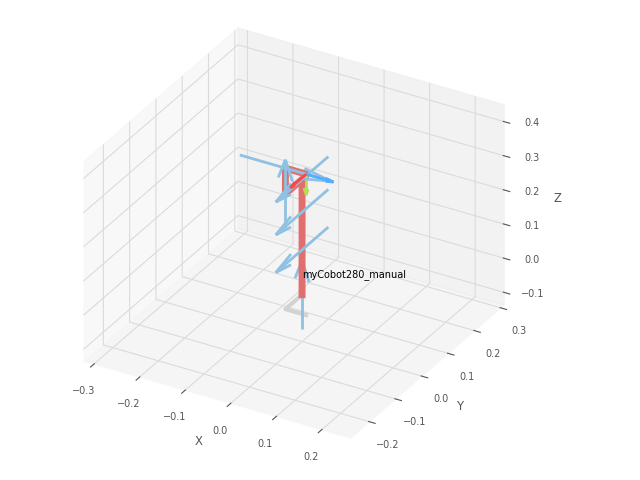

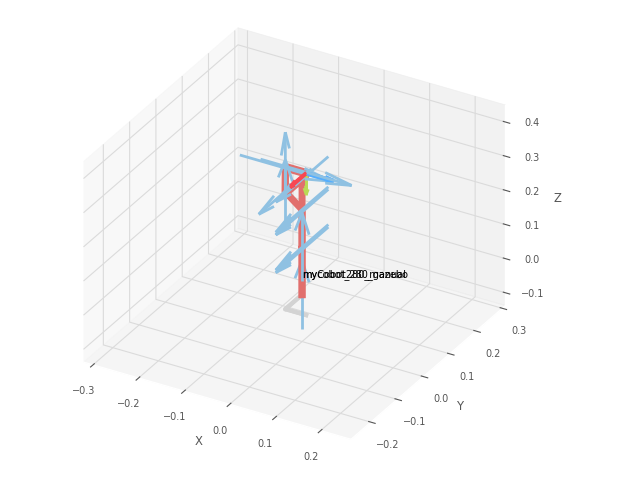

In [13]:
home = np.zeros(6)
manual_robot.q = home.copy()
urdf_robot.q = home.copy()
robot_fig = manual_robot.plot(home, backend="pyplot", block=False)
robot_fig.add(urdf_robot)
robot_fig.step()

### 12. Compare the transforms in terms of end-effector position and orientation
Use `fkine(config).A` to compare the transform from the simplified manual DH model base to your manual tool frame and the transform from `g_base` to `joint6_flange` in the URDF model at home configuration. Compare translation and orientation separately. Small discrepancies can come from the modeling convention itself and, in the full controller stack, from calibrated base/tool correction terms. Note: you can extract the homogeneous transform as a NumPy array from the `.A` member of the transform object.

In [13]:
home = np.zeros(6)
thome = manual_robot.fkine(home).A
urdf_home = urdf_fk(home)
print("Manual home transform:\n", thome)
print("URDF g_base to joint6_flange:\n", urdf_home)
report_pose_error(thome, urdf_home)

Manual home transform:
 [[-6.12323400e-17  1.83697020e-16  1.00000000e+00  4.56000000e-02]
 [-1.00000000e+00 -3.74939946e-33 -6.12323400e-17 -6.34000000e-02]
 [-7.49879891e-33 -1.00000000e+00  1.83697020e-16  4.12670000e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
URDF g_base to joint6_flange:
 [[ 0.00000000e+00 -3.67319161e-06  1.00000000e+00  4.56000351e-02]
 [-1.00000000e+00  3.67321860e-06  1.34924357e-11 -6.36210270e-02]
 [-3.67321860e-06 -1.00000000e+00 -3.67319161e-06  4.18139766e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Position difference: 5.474230 mm
Orientation difference: 0.000298 deg


### 13. Verify FK at a known configuration
Evaluate both models at the configuration $\boldsymbol{q} = [0,\; -\pi/2,\; 0,\; 0,\; 0,\; 0]$ and compare the resulting end-effector positions. This gives you a numerical sanity check before moving on.

In [14]:
q_test = np.array([0, -np.pi/2, 0, 0, 0, 0])
t_manual = manual_robot.fkine(q_test).A
t_urdf = urdf_fk(q_test)
print("Manual FK end-effector position (m):", t_manual[:3, 3])
print("URDF FK end-effector position (m):", t_urdf[:3, 3])
report_pose_error(t_manual, t_urdf)

Manual FK end-effector position (m): [ 0.28145 -0.0634   0.08562]
URDF FK end-effector position (m): [ 0.27957977 -0.06362069  0.0929595 ]
Position difference: 7.577249 mm
Orientation difference: 0.000516 deg


### 14. Transform between the end-effector frames in Euler angles
If your simplified manual DH model and the URDF model differ in end-effector orientation, compute the relative transform

$\boldsymbol{H}_d = \boldsymbol{H}_{ee,manual}^{-1} \boldsymbol{H}_{ee,urdf}$

This is the same type of frame-comparison task you practiced in the Lab 1 notebook.

In [15]:
# Reset the tool so rerunning the comparison does not accumulate corrections.
manual_robot.tool = manual_tool
thome_uncorrected = manual_robot.fkine(home).A
urdf_home = urdf_fk(home)
delta = np.linalg.inv(thome_uncorrected) @ urdf_home
print(delta)

[[ 1.00000000e+00 -3.67321860e-06 -1.34924970e-11  2.21026955e-04]
 [ 3.67321860e-06  1.00000000e+00  3.67319161e-06 -5.46976631e-03]
 [ 6.12316652e-17 -3.67319161e-06  1.00000000e+00  3.51120686e-08]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


Convert the relative orientation to roll-pitch-yaw angles and interpret which axis conventions differ between the two end-effector frames.

In [16]:
euldelta = tr2rpy(delta, order='zyx')
print("Relative roll, pitch, yaw (rad):", euldelta)
print("Relative roll, pitch, yaw (deg):", np.rad2deg(euldelta))

Relative roll, pitch, yaw (rad): [-3.67319161e-06 -6.12316652e-17  3.67321860e-06]
Relative roll, pitch, yaw (deg): [-2.10458377e-04 -3.50831599e-15  2.10459923e-04]


### 15. Apply a candidate tool correction
Apply the full relative transform `delta` (translation and rotation). This forces agreement at home, but does not prove that the models describe the same mechanism. The simplified DH geometry differs from the supplied URDF; a constant tool transform generally cannot correct geometry or joint-axis differences throughout the workspace.

In [17]:
# apply the correction to the manual end-effector frame
manual_robot.tool = manual_tool * SE3(delta)
# thome after orientation compensation
thome = manual_robot.fkine(home).A
print(thome)

[[ 0.00000000e+00 -3.67319161e-06  1.00000000e+00  4.56000351e-02]
 [-1.00000000e+00  3.67321860e-06  1.34924357e-11 -6.36210270e-02]
 [-3.67321860e-06 -1.00000000e+00 -3.67319161e-06  4.18139766e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


### 16. Compare both models
Plot both models again and check whether the corrected manual tool frame is closer to the URDF end-effector frame. In the remaining tasks, use the URDF model as the reference kinematic model for the live ROS 2 controller stack.

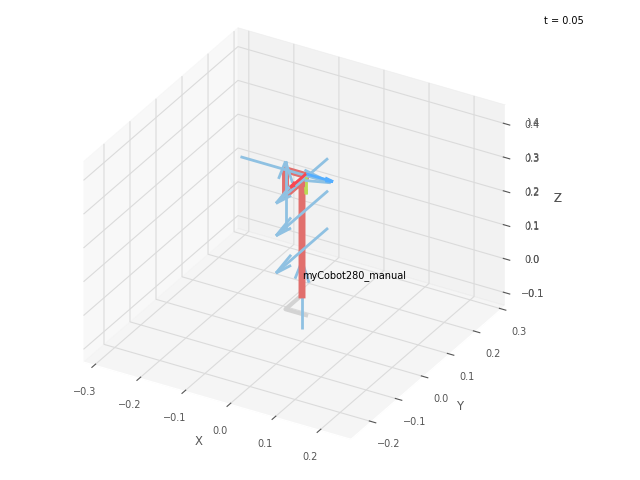

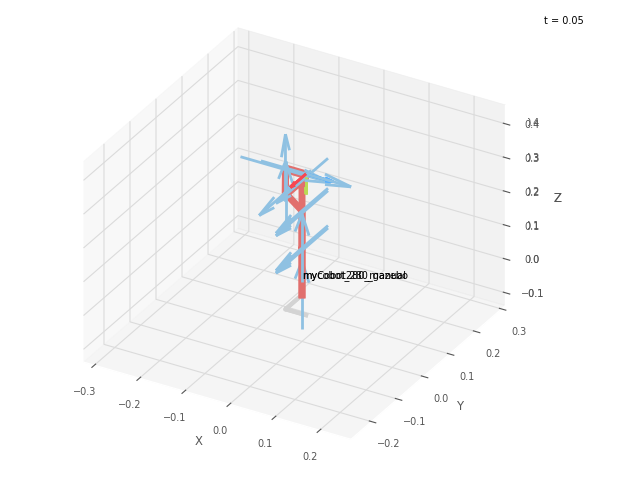

Position difference: 0.000000 mm
Orientation difference: 0.000000 deg
The correction aligns the end-effector frames at home only.


In [18]:
manual_robot.q = home.copy()
urdf_robot.q = home.copy()
robot_2 = manual_robot.plot(home, backend="pyplot", block=False)
robot_2.add(urdf_robot)
robot_2.step()
thome = manual_robot.fkine(home).A
report_pose_error(thome, urdf_fk(home))
assert np.allclose(thome, urdf_fk(home), atol=1e-9)
print("The correction aligns the end-effector frames at home only.")

### 17. Create a random configuration
Sample a reproducible configuration within the URDF joint limits. Compare the corrected manual model against the explicit `g_base` to `joint6_flange` chain. Residual error away from home reveals differences that the home tool correction cannot remove.

The plot connects the origins of the model frames; it is a kinematic skeleton, not a rendering of the robot housing. Blue shows the URDF and dashed orange shows the manual DH model. Full-range random angles can produce a tightly folded pose; joint limits alone do not guarantee a collision-free configuration. This sample is for offline comparison.


Position difference: 12.735044 mm
Orientation difference: 0.000636 deg
Joint angles (deg): [167.2  61.6  80.8  78.3 111.6 -26.5]


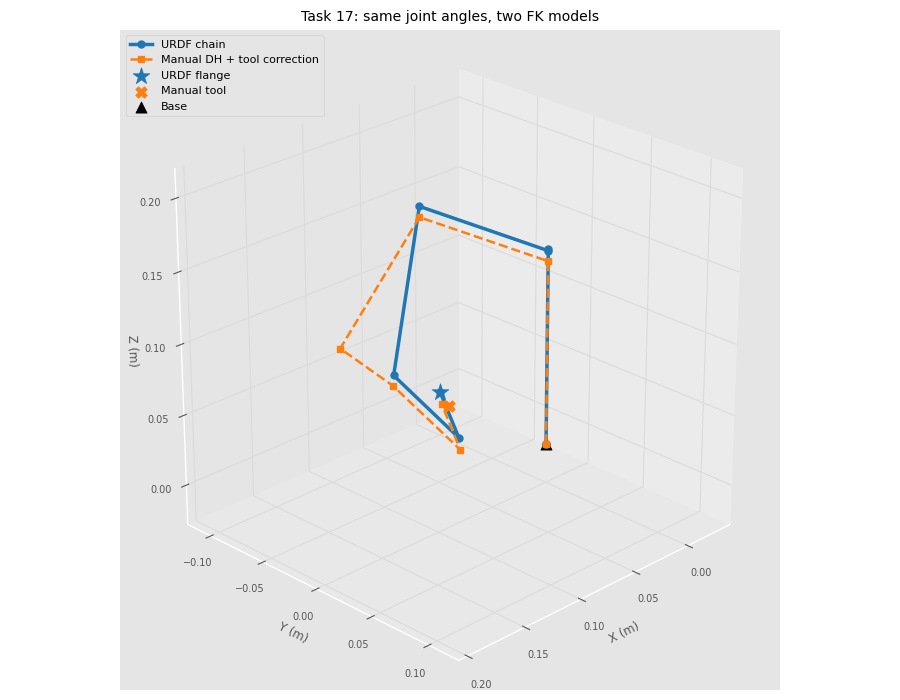

In [19]:
# Reproducible sample within the URDF joint limits (radians).
rng = np.random.default_rng(280)
randq = rng.uniform(urdf_robot.qlim[0], urdf_robot.qlim[1])
urdf_randq = randq.copy()
trandq = manual_robot.fkine(randq).A
urdf_trandq = urdf_fk(randq)
report_pose_error(trandq, urdf_trandq)

# Draw frame origins as a clean kinematic skeleton, without overlapping
# joint arrows, frame labels, or floor shadows. These lines are not meshes.
import matplotlib.pyplot as plt

manual_points = np.array([T.t for T in manual_robot.fkine_all(randq)])
manual_points = np.vstack((manual_points, trandq[:3, 3]))
urdf_points = np.array([
    urdf_robot.fkine(randq, start="g_base", end=link).t
    for link in ["g_base", "joint1", "joint2", "joint3", "joint4",
                 "joint5", "joint6", "joint6_flange"]
])

# Close this task's previous figure when rerunning the cell.
if "task17_fig" in globals():
    plt.close(task17_fig)
task17_fig = plt.figure(figsize=(9, 7))
ax = task17_fig.add_subplot(111, projection="3d")
ax.plot(*urdf_points.T, "o-", color="tab:blue", linewidth=2.5,
        markersize=5, label="URDF chain")
ax.plot(*manual_points.T, "s--", color="tab:orange", linewidth=1.8,
        markersize=4, label="Manual DH + tool correction")
ax.scatter(*urdf_trandq[:3, 3], color="tab:blue", marker="*", s=160,
           label="URDF flange")
ax.scatter(*trandq[:3, 3], color="tab:orange", marker="X", s=70,
           label="Manual tool")
ax.scatter(0, 0, 0, color="black", marker="^", s=65, label="Base")

# Identical axis spans prevent distortion of the robot's proportions.
points = np.vstack((manual_points, urdf_points))
center = (points.min(axis=0) + points.max(axis=0)) / 2
half_span = max(np.ptp(points, axis=0).max() * 0.65, 0.10)
ax.set_xlim(center[0] - half_span, center[0] + half_span)
ax.set_ylim(center[1] - half_span, center[1] + half_span)
ax.set_zlim(center[2] - half_span, center[2] + half_span)
ax.set_box_aspect((1, 1, 1))
ax.set(xlabel="X (m)", ylabel="Y (m)", zlabel="Z (m)",
       title="Task 17: same joint angles, two FK models")
ax.view_init(elev=25, azim=45)
ax.legend(loc="upper left", fontsize=8)
task17_fig.tight_layout()
print("Joint angles (deg):", np.round(np.rad2deg(randq), 1))
plt.show()


## ROS 2 Integration for the myCobot 280
Run the remaining tasks from the same activated environment used for Jupyter: `source ~/venvs/mycobot/bin/activate`

The control stack for the labs is launched with `ros2 launch mycobot_control mycobot_control.launch.py`.


### 18. Launch the myCobot control stack
Open a separate terminal, activate `~/venvs/mycobot`, and launch the controller:

```bash
source ~/venvs/mycobot/bin/activate
ros2 launch mycobot_control mycobot_control.launch.py
```

Keep that process running while you inspect topics and publish commands from this notebook.

### 19. Inspect the ROS 2 interfaces
Use the ROS 2 CLI to inspect the live interfaces used in the lab stack:

```bash
ros2 topic list
ros2 topic info /mycobot/joint_states
ros2 topic info /mycobot/joint_command
ros2 topic info /mycobot/joint_velocity
ros2 topic info /mycobot/ee_pose
ros2 interface show sensor_msgs/msg/JointState
ros2 interface show std_msgs/msg/Float64MultiArray
```

### 20. Visualize in RViz2
RViz needs transforms published by `robot_state_publisher`; a `JointState` topic is not a TF topic. In a terminal with ROS 2 and the workspace sourced, run the following from `mycobot_ws` (unless a state publisher is already running):

```bash
ros2 run robot_state_publisher robot_state_publisher notebooks/mycobot_280_gazebo.urdf --ros-args -r joint_states:=/mycobot/joint_states
```

Launch `rviz2` in another sourced terminal. Set **Fixed Frame** to `g_base`, add **RobotModel** using `/robot_description`, and optionally add **TF** to inspect `/tf` and `/tf_static`. Mesh visualization requires the `mycobot_description` package and its meshes to be installed and discoverable. Verify incoming state with `ros2 topic echo /mycobot/joint_states --once`.

## ROS 2 Node and Topics
### 21. Observe state and identify command topics
Confirm that `/mycobot/joint_states` is published by the controller as `JointState`. The active command topics for later labs are `/mycobot/joint_command`, `/mycobot/joint_velocity`, and `/mycobot/ee_pose`, all using `Float64MultiArray`. The controller publishes joint names `joint1` through `joint6` in the `JointState` message. The `.position` field contains the six joint angles in radians. The `/mycobot/ee_pose` command topic expects `[x_mm, y_mm, z_mm, roll_deg, pitch_deg, yaw_deg]`. The controller converts these to metres and radians internally before solving IK. This topic is used in later labs.

In [20]:
import time

import rclpy
from rclpy.node import Node
from sensor_msgs.msg import JointState
from std_msgs.msg import Float64MultiArray


class MyCobotNotebookNode(Node):
    def __init__(self):
        super().__init__('mycobot_fk_notebook')
        self.last_joint_state = None
        self.joint_state_sub = self.create_subscription(
            JointState,
            '/mycobot/joint_states',
            self.joint_state_callback,
            10,
        )

    def joint_state_callback(self, msg):
        self.last_joint_state = msg


### 22. Initialize a ROS 2 notebook node
Initialize `rclpy`, create a small notebook node, and spin it briefly whenever you want to process incoming `/mycobot/joint_states` messages.

In [21]:
# Destroy the previous notebook node before rerunning this cell.
if "node" in globals() and rclpy.ok():
    node.destroy_node()
if not rclpy.ok():
    rclpy.init(args=None)
node = MyCobotNotebookNode()
# Rerun the publisher cell after recreating this node.

### 23. Query the topics that are currently available
Use the ROS 2 CLI from a terminal or a Jupyter shell cell to inspect the active topics. Then spin the notebook node once and check whether a `JointState` message arrives on `/mycobot/joint_states`.

In [22]:
# Terminal commands
# !ros2 topic list
# !ros2 topic info /mycobot/joint_states
# !ros2 topic info /mycobot/joint_command
# !ros2 topic echo /mycobot/joint_states --once
# !ros2 interface show sensor_msgs/msg/JointState
# !ros2 interface show std_msgs/msg/Float64MultiArray

rclpy.spin_once(node, timeout_sec=0.5)
print(node.last_joint_state)


None


## ROS 2 Subscriber and Publisher
### 24. Create a publisher
The controller already publishes `/mycobot/joint_states`, so do not publish to that topic. Instead, create a publisher for `/mycobot/joint_command` with the message type `std_msgs/msg/Float64MultiArray`.

In [23]:
joint_command_publisher = node.create_publisher(
    Float64MultiArray,
    '/mycobot/joint_command',
    10,
)


### 25. Create an empty command message
Create an empty `Float64MultiArray` message for `/mycobot/joint_command` and inspect its field structure. The controller publishes measured or estimated joint states on `/mycobot/joint_states`; this notebook sends desired joint positions on `/mycobot/joint_command`.

In [24]:
joint_command_msg = Float64MultiArray()
print(joint_command_msg)

std_msgs.msg.Float64MultiArray(layout=std_msgs.msg.MultiArrayLayout(dim=[], data_offset=0), data=[])


### 26. Assign a joint vector to the message
Copy a 6-element joint configuration into the `.data` field of the command message. You can use `randq` from the previous section or define a simple test configuration that stays within the safe lab workspace.

**Important:** The `/mycobot/joint_command` topic expects joint angles in radians. The controller internally converts to degrees before sending to the hardware.

In [25]:
q_cmd = np.zeros(6)

def validate_q(q):
    q = np.asarray(q, dtype=float)
    if q.shape != (6,) or not np.all(np.isfinite(q)):
        raise ValueError("Expected six finite joint angles in radians.")
    if np.any(q < urdf_robot.qlim[0]) or np.any(q > urdf_robot.qlim[1]):
        raise ValueError("Joint configuration exceeds URDF limits.")
    return q

joint_command_msg.data = validate_q(q_cmd).tolist()

### 27. Inspect the observed joint state
Spin the notebook node once and inspect the latest `/mycobot/joint_states` message. Compare the observed state topic with the joint-position command vector you are about to send.

In [26]:
rclpy.spin_once(node, timeout_sec=0.5)
print(node.last_joint_state)

None


### 28. Publish joint-position commands
Publish the `Float64MultiArray` command on `/mycobot/joint_command`. The controller should interpret this as a desired joint-position command for the myCobot 280.

In [27]:
joint_command_publisher.publish(joint_command_msg)

If the robot or visualization does not respond, make sure the controller launch is running from the same `~/venvs/mycobot` environment and verify the topic names again with `ros2 topic list`.

### 29. Publish a simple interpolated joint-space trajectory
Implement a notebook-friendly loop that sends intermediate joint-position commands
\begin{equation}
\boldsymbol{q}_t = \boldsymbol{q}_i + (\boldsymbol{q}_f - \boldsymbol{q}_i) \frac{t}{t_f}
\end{equation}
from an initial configuration `qi` to a target configuration `qf` over a duration `t_f`. Publish the interpolated vectors on `/mycobot/joint_command` and optionally inspect `/mycobot/joint_states` during the loop. This linear interpolation is a simple baseline. Lab 6 (Trajectory Planning) replaces it with smoother trapezoidal and polynomial velocity profiles that respect acceleration limits.

In [28]:
# Set True when ready to send this trajectory to the connected controller.
publish_ros2 = False
rate_hz = 20.0
dt = 1.0 / rate_hz
max_time = 4.0
qf = validate_q([np.pi/2, -np.pi/2, np.pi/2, 0, np.pi/3, -np.pi/3])

if publish_ros2:
    # Wait for a fresh measurement, then order positions by joint name.
    node.last_joint_state = None
    deadline = time.monotonic() + 2.0
    while node.last_joint_state is None and time.monotonic() < deadline:
        rclpy.spin_once(node, timeout_sec=0.1)
    msg = node.last_joint_state
    if msg is None:
        raise RuntimeError("No fresh joint state received; trajectory not sent.")
    positions = dict(zip(msg.name, msg.position))
    names = [f"joint{i}" for i in range(1, 7)]
    if any(name not in positions for name in names):
        raise ValueError("Joint state must include joint1 through joint6.")
    qi = validate_q([positions[name] for name in names])
else:
    qi = validate_q(np.zeros(6))

start_time = time.monotonic()
while True:
    tau = min((time.monotonic() - start_time) / max_time, 1.0)
    qinterp = qi + (qf - qi) * tau
    if publish_ros2:
        joint_command_msg.data = validate_q(qinterp).tolist()
        joint_command_publisher.publish(joint_command_msg)
        rclpy.spin_once(node, timeout_sec=0.0)
    if tau >= 1.0:  # Publish the exact final target before exiting.
        break
    time.sleep(dt)
print("Final joint vector (rad):", qinterp)

# Optional cleanup:
# node.destroy_node()
# rclpy.shutdown()

Final joint vector (rad): [ 1.57079633 -1.57079633  1.57079633  0.          1.04719755 -1.04719755]
